In [1]:
from pathlib import Path 
import sys
import ProbabilisticParcellation.util as ut
import ProbabilisticParcellation.individ_group as ig
import ProbabilisticParcellation.plot as ppp
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd
import numpy as np
import scipy.stats as ss
import IndividualParcellation.scripts.paths as paths




/Users/callithrix/code/Python/IndividualParcellation/env/lib/python3.9/site-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/tensor/python_tensor.cpp:453.)
  _C._set_default_tensor_type(t)


## Individual vs. group analysis

To reproduce results, run evaluate_mdtb_rest in scripts.rest.evaluation

In [2]:
base_dir = paths.set_base_dir() 
results_dir = paths.set_results_dir(base_dir)
data_dir = paths.set_fusion_dir(base_dir)
# Data = pd.read_csv(results_dir + '/evaluation/kappa_curve-fine_general_general_eq.tsv', sep='\t')
Data = pd.read_csv(results_dir + '/evaluation/kappa_curve-fine_all_models.tsv', sep='\t')


In [3]:
T = pd.read_csv(f'{data_dir}/MDTB/participants.tsv', delimiter='\t')
participants = T.participant_id
rest_subjects = participants[T['ses-rest'] == 1].tolist()

In [4]:
Data.head()

,sn,num_runs,max_dist,bin_width,kappa,DCBC,mask,dtype,mtype
0,0,2,40,1.5,0.0,0.087443,motor,Net67Run,general
1,1,2,40,1.5,0.0,0.065786,motor,Net67Run,general
2,2,2,40,1.5,0.0,0.022702,motor,Net67Run,general
3,3,2,40,1.5,0.0,0.083136,motor,Net67Run,general
4,4,2,40,1.5,0.0,-0.000827,motor,Net67Run,general


(0.0, 1.0)

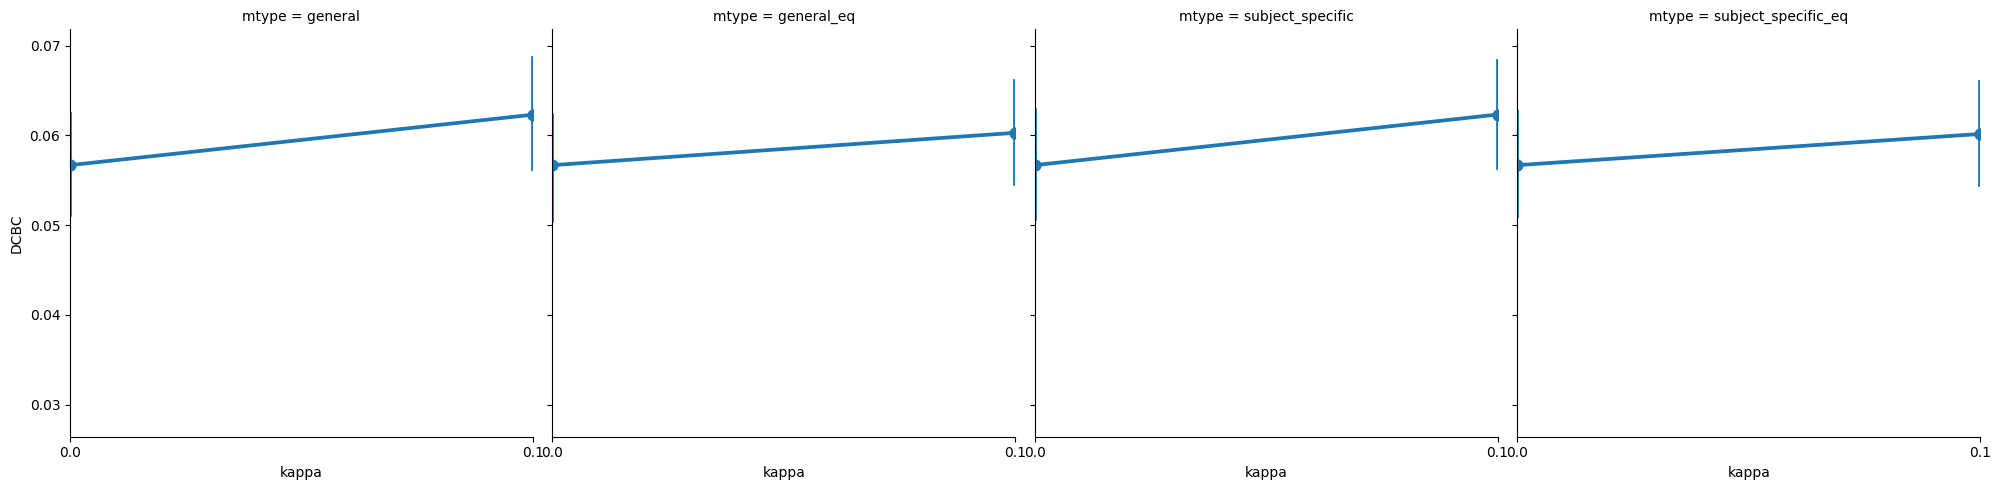

In [5]:
sb.catplot(x='kappa', y='DCBC', col='mtype', data=Data, kind='point')
plt.xlim(0, 1)

In [6]:
Data


,sn,num_runs,max_dist,bin_width,kappa,DCBC,mask,dtype,mtype
0,0,2,40,1.5,0.0,0.087443,motor,Net67Run,general
1,1,2,40,1.5,0.0,0.065786,motor,Net67Run,general
2,2,2,40,1.5,0.0,0.022702,motor,Net67Run,general
3,3,2,40,1.5,0.0,0.083136,motor,Net67Run,general
4,4,2,40,1.5,0.0,-0.000827,motor,Net67Run,general
...,...,...,...,...,...,...,...,...,...
6795,12,2,40,1.5,8.0,0.046661,whole,Fus06Run,subject_specific_eq
6796,13,2,40,1.5,8.0,0.069503,whole,Fus06Run,subject_specific_eq
6797,14,2,40,1.5,8.0,0.028489,whole,Fus06Run,subject_specific_eq
6798,15,2,40,1.5,8.0,0.019543,whole,Fus06Run,subject_specific_eq


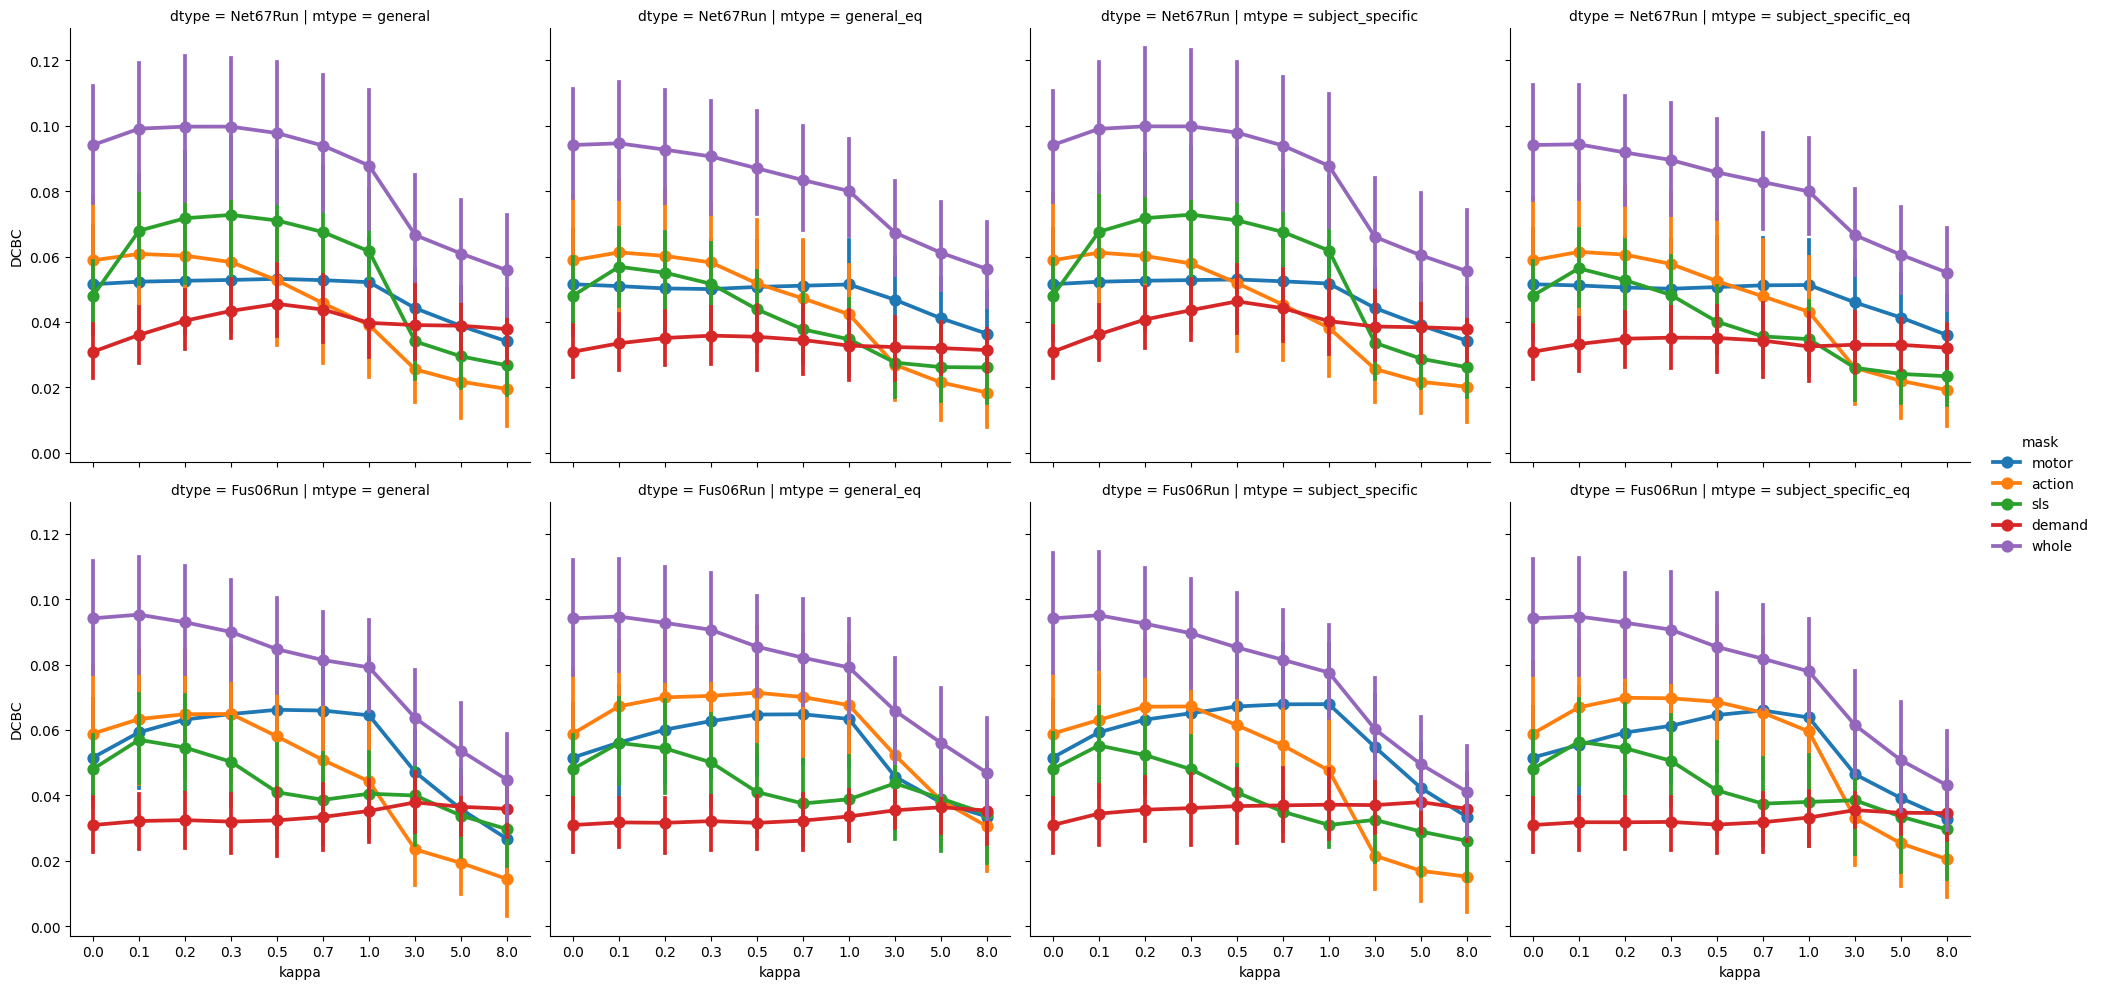

In [7]:
# Make connected line plot with catplot
sb.catplot(x='kappa', y='DCBC', col='mtype', hue='mask', row='dtype', data=Data, kind='point')
# plt.xlim(-0.1, 8)
# add a grid
# plt.grid()


In [8]:
# Show only values where mask == whole
whole_mean = Data.groupby(['mtype', 'mask', 'dtype', 'kappa']).mean().query('mask == "whole"')
# whole_mean.query('mtype == "subject_specific"').iloc[0:20]
# # Find kappa value where DCBC is maximum
# whole_mean.idxmax()
# Show dcbc value where kappa is maximum
whole_mean


sn  num_runs  max_dist  bin_width  \
mtype               mask  dtype    kappa                                       
general             whole Fus06Run 0.0    8.0       2.0      40.0        1.5   
                                   0.1    8.0       2.0      40.0        1.5   
                                   0.2    8.0       2.0      40.0        1.5   
                                   0.3    8.0       2.0      40.0        1.5   
                                   0.5    8.0       2.0      40.0        1.5   
...                                       ...       ...       ...        ...   
subject_specific_eq whole Net67Run 0.7    8.0       2.0      40.0        1.5   
                                   1.0    8.0       2.0      40.0        1.5   
                                   3.0    8.0       2.0      40.0        1.5   
                                   5.0    8.0       2.0      40.0        1.5   
                                   8.0    8.0       2.0      40.0        1.5   

                                              DCBC  
mtype               mask  dtype    kappa            
general             whole Fus06Run 0.0    0.094140  
                                   0.1    0.095265  
                                   0.2    0.092927  
                                   0.3    0.089949  
                                   0.5    0.084669  
...                                            ...  
subject_specific_eq whole Net67Run 0.7    0.082799  
                                   1.0    0.079936  
                                   3.0    0.066576  
                                   5.0    0.060578  
                                   8.0    0.055127  

[80 rows x 5 columns]

# Significance test

In [9]:
# Test whether DCBC at kappa 0.2 for Net67Run and subject_specific is significantly different from Net67Run and subject_specific at kappa 0
selected_model = Data.query('mtype == "subject_specific" and mask == "whole" and dtype == "Net67Run"')

x = selected_model.query('kappa == 0.2').DCBC
y = selected_model.query('kappa == 0').DCBC
ss.ttest_rel(x, y)


TtestResult(statistic=1.8910857365314009, pvalue=0.07686052999713747, df=16)

(0.0, 1.0)

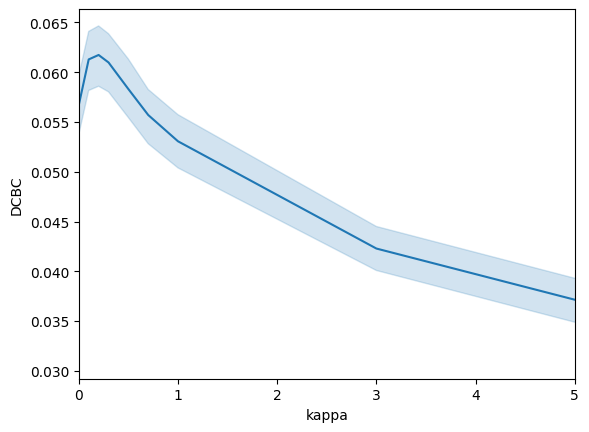

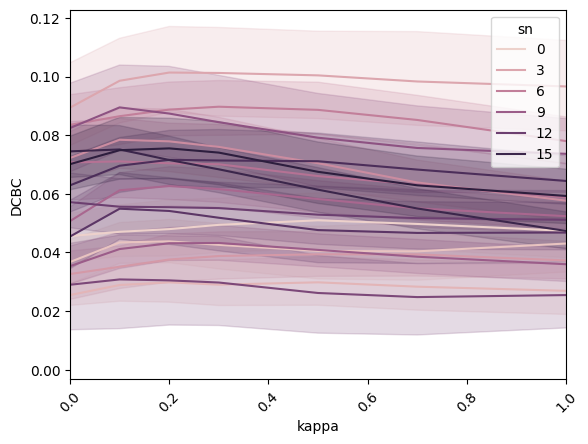

In [10]:
sb.lineplot(x='kappa', y='DCBC', data=Data)
plt.xlim(0, 5)

plt.figure()
sb.lineplot(x='kappa', y='DCBC',hue='sn', data=Data)
# rotate x-axis labels
plt.xticks(rotation=45)
# Make xlimits between 0 and 5
plt.xlim(0, 1)


(0.0, 5.0)

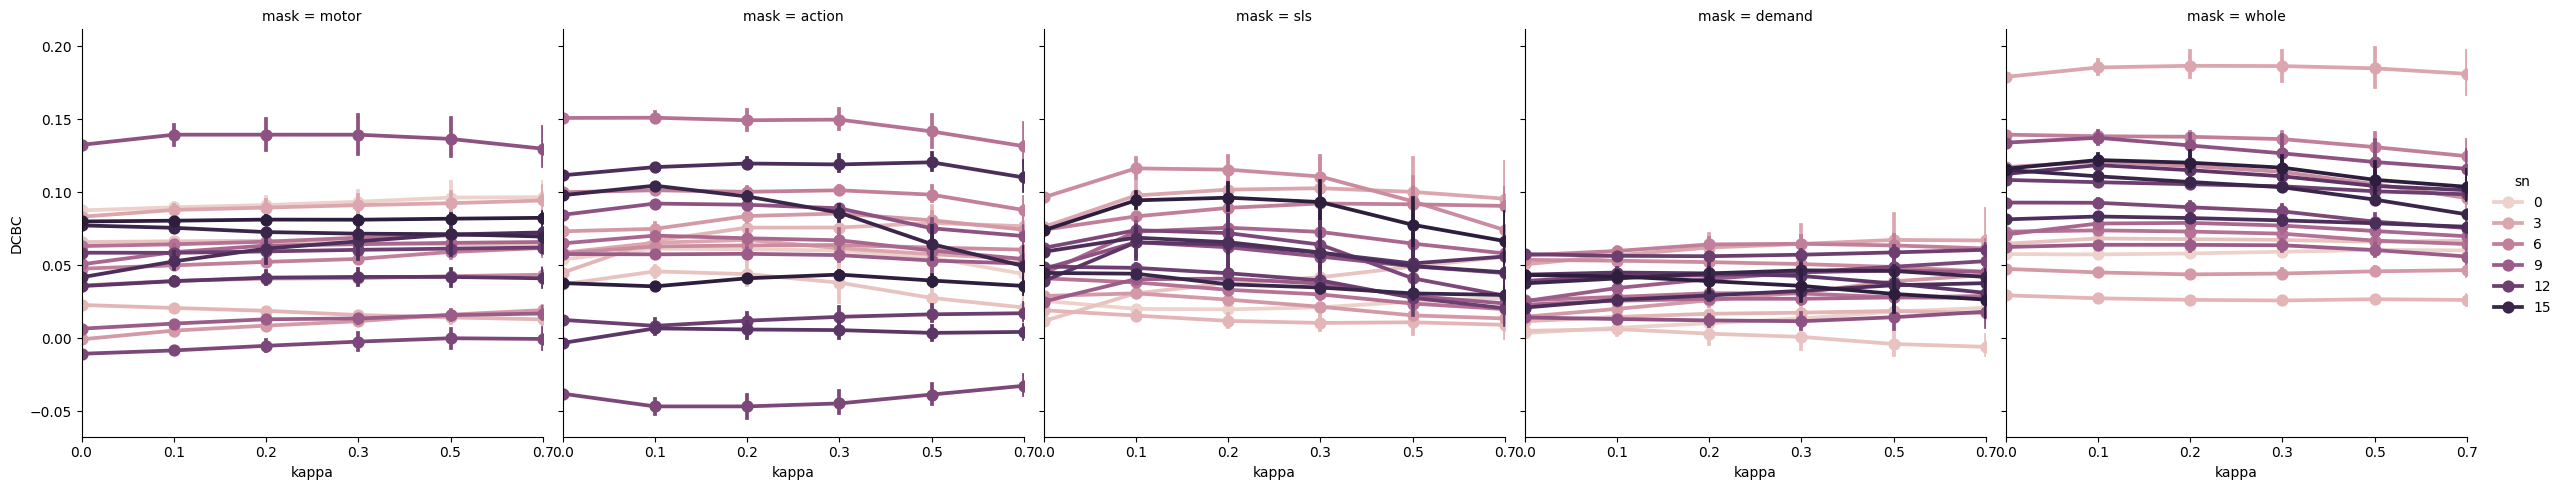

In [11]:
# Make connected line plot with catplot
sb.catplot(x='kappa', y='DCBC', col='mask', hue='sn', data=Data, kind='point')
plt.xlim(0, 5)


<Axes: xlabel='kappa', ylabel='DCBC'>

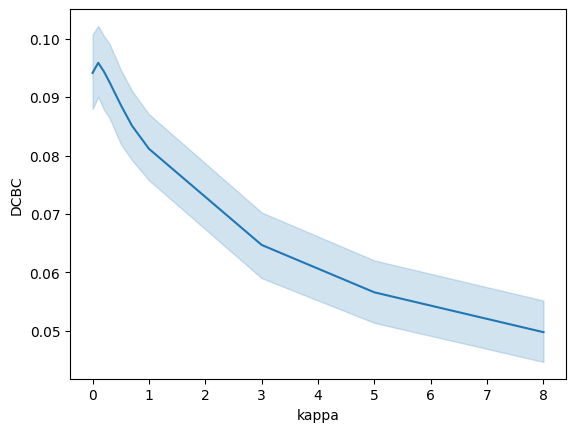

In [12]:
# Plot mean into the same figure
sb.lineplot(x='kappa', y='DCBC', data=Data[Data['mask'] == 'whole'])

# Validation

In [18]:
Data_validation = pd.read_csv(results_dir + '/evaluation/kappa_curve-fine_test-s2_all_models.tsv', sep='\t')


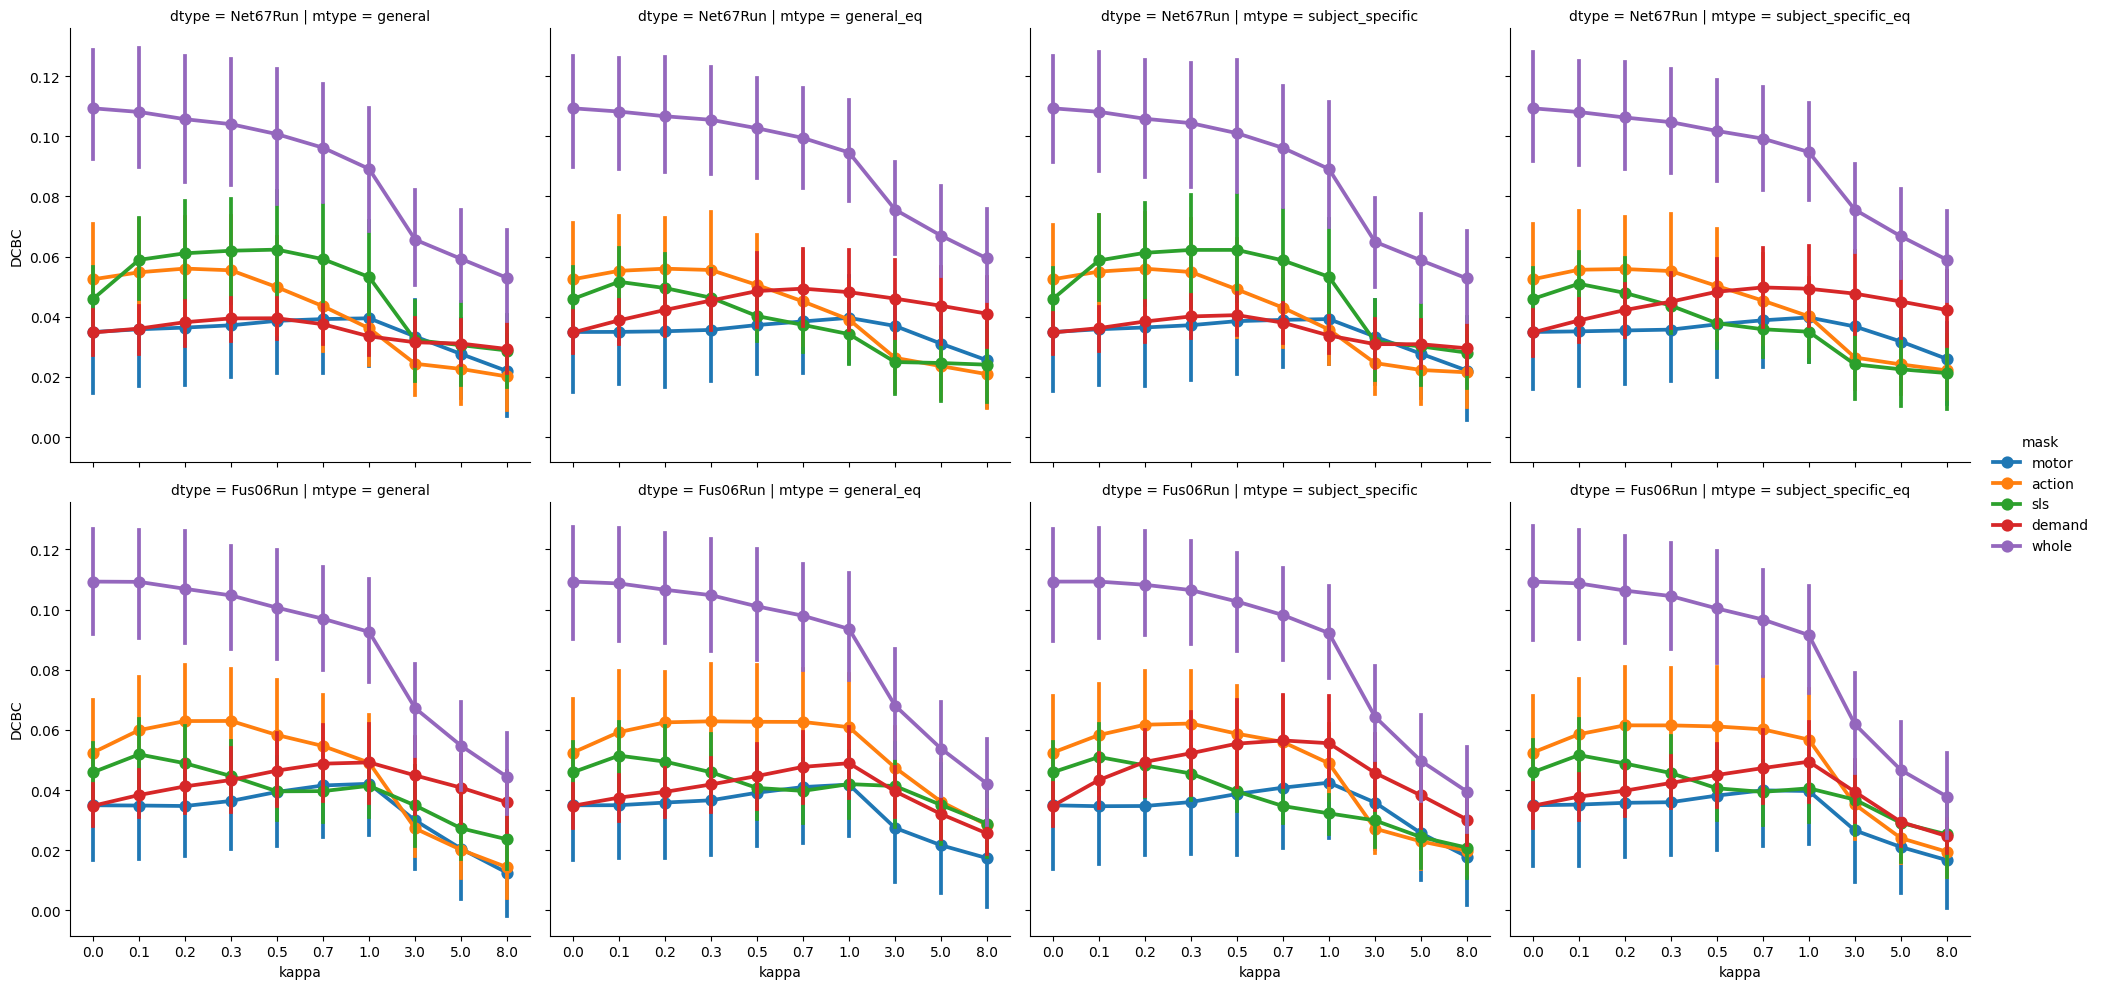

In [19]:
sb.catplot(x='kappa', y='DCBC', col='mtype', hue='mask', row='dtype', data=Data_validation, kind='point')


In [20]:
# Show only values where mask == whole
whole_mean = Data_validation.groupby(['mtype', 'mask', 'dtype', 'kappa']).mean().query('mask == "whole"')
# whole_mean.query('mtype == "subject_specific"').iloc[0:20]
# # Find kappa value where DCBC is maximum
whole_mean.idxmax()
# Show dcbc value where kappa is maximum
# whole_mean


sn                    (general, whole, Fus06Run, 0.0)
num_runs              (general, whole, Fus06Run, 0.0)
max_dist              (general, whole, Fus06Run, 0.0)
bin_width             (general, whole, Fus06Run, 0.0)
DCBC         (subject_specific, whole, Fus06Run, 0.1)
dtype: object

In [23]:
# Test whether DCBC at kappa 0.1 for Fus06Run and subject_specific is significantly different from Fus06Run and subject_specific at kappa 0
selected_model = Data_validation.query('mtype == "subject_specific" and mask == "whole" and dtype == "Net67Run"')

x = selected_model.query('kappa == 0.1').DCBC
y = selected_model.query('kappa == 0').DCBC
ss.ttest_rel(x, y)


TtestResult(statistic=-0.8215905492194798, pvalue=0.4233841010147661, df=16)

In [24]:
# Test whether s1 best kappa performs best here:
# Test if DCBC at kappa 0.3 for Net67Run and subject_specific is significantly different from Net67Run and subject_specific at kappa 0
selected_model = Data_validation.query('mtype == "subject_specific" and mask == "whole" and dtype == "Net67Run"')

x = selected_model.query('kappa == 0.2').DCBC
y = selected_model.query('kappa == 0').DCBC
ss.ttest_rel(x, y)


TtestResult(statistic=-1.6293175605296601, pvalue=0.12277253149612452, df=16)